# CVAE (Conditional VAE, Conditional Variational Autoencoder)

### 條件式變分自編碼器
在 encoder/decoder 中加入 條件變數（label、屬性等），控制生成內容

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 檢查 GPU、mps與 CPU 可用性
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [2]:
# 使用 scikit-learn 的 MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(np.int64)

# 訓練 / 測試切割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# 轉為 Tensor 並 reshape 成 [B, C, H, W]
X_train = torch.tensor(X_train).view(-1, 1, 28, 28)
X_test = torch.tensor(X_test).view(-1, 1, 28, 28)
y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=128, shuffle=False)

## 定義 Conditional CVAE 模型

條件式 VAE 會將 label（類別）嵌入成 one-hot vector 並與影像特徵結合。

In [3]:
class ConditionalCVAE(nn.Module):
    def __init__(self, latent_dim=20, num_classes=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Label embedding 轉為 one-hot
        self.embed_y = nn.Embedding(num_classes, num_classes)

        # Encoder：影像 + label one-hot 一起輸入
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1 + 1, 32, 4, 2, 1),  # 加上 label channel
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # Decoder：latent + label 一起輸入
        self.fc_dec = nn.Linear(latent_dim + num_classes, 64 * 7 * 7)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x, y):
        # 將 label one-hot 展成 channel (H, W)
        y = self.embed_y(y)
        y = y.unsqueeze(2).unsqueeze(3).expand(-1, -1, 28, 28)
        x = torch.cat([x, y[:, :1]], dim=1)  # 只加一個channel避免過多輸入
        h = self.enc_conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y = self.embed_y(y)
        z = torch.cat([z, y], dim=1)
        h = self.fc_dec(z)
        h = h.view(-1, 64, 7, 7)
        return self.dec_conv(h)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, y)
        return recon_x, mu, logvar


In [4]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

model = ConditionalCVAE(latent_dim=20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [5]:
epochs = 10
model.train()

for epoch in range(epochs):
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = vae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}]  Loss: {total_loss / len(train_loader.dataset):.4f}")


Epoch [1/10]  Loss: 151.0684
Epoch [2/10]  Loss: 109.9032
Epoch [3/10]  Loss: 105.2818
Epoch [4/10]  Loss: 103.2320
Epoch [5/10]  Loss: 101.8499
Epoch [6/10]  Loss: 100.7371
Epoch [7/10]  Loss: 99.9770
Epoch [8/10]  Loss: 99.2717
Epoch [9/10]  Loss: 98.7453
Epoch [10/10]  Loss: 98.1714


## 檢視重建影像

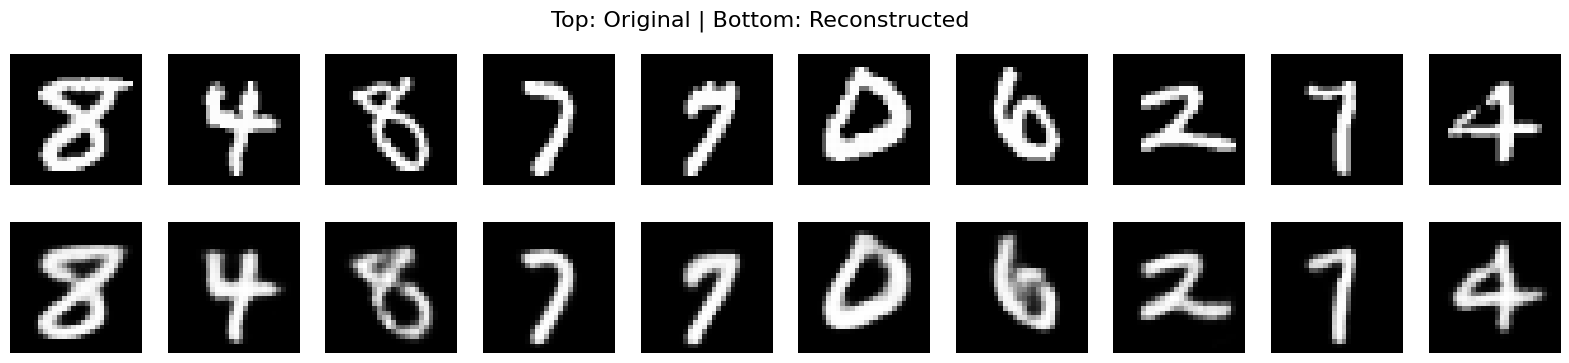

In [6]:
model.eval()
with torch.no_grad():
    x, y = next(iter(test_loader))
    x, y = x.to(device), y.to(device)
    recon_x, _, _ = model(x, y)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon_x[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Top: Original | Bottom: Reconstructed", fontsize=16)
plt.show()


## 控制生成指定數字

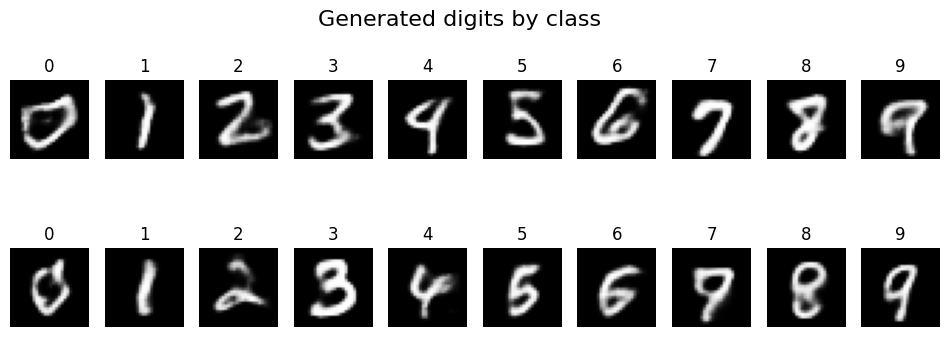

In [10]:
# 生成兩排，每排都是每個數字的圖像 (0–9)
model.eval()

with torch.no_grad():
    z = torch.randn(20, model.latent_dim).to(device)
    #labels從0-9重複兩次
    labels = torch.cat([torch.arange(0, 10).to(device)] * 2)
    gen_imgs = model.decode(z, labels).cpu()

plt.figure(figsize=(12, 4))
for i in range(20):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(gen_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(str(i % 10))
plt.suptitle("Generated digits by class", fontsize=16)
plt.show()


## Latent Space 2D Visualization

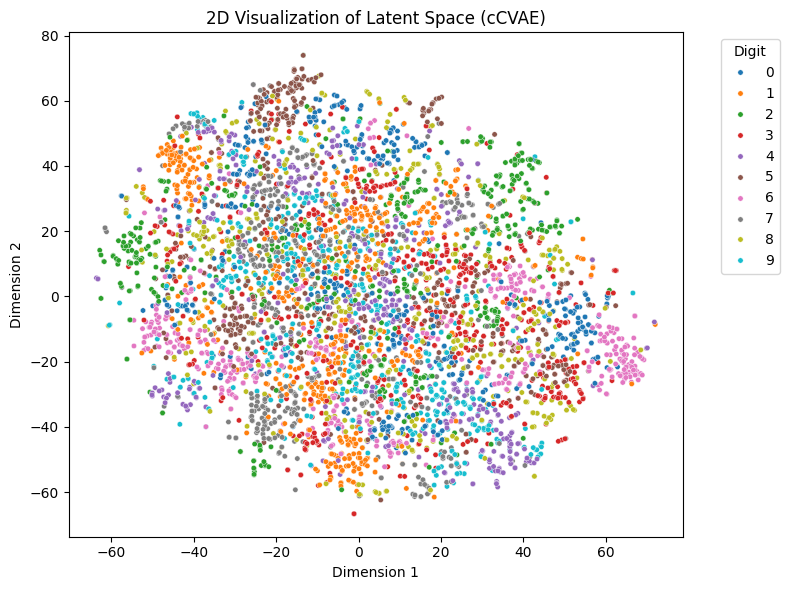

In [8]:
from sklearn.manifold import TSNE
import seaborn as sns

model.eval()
latents, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        mu, logvar = model.encode(x, y)
        z = model.reparameterize(mu, logvar)
        latents.append(z.cpu())
        labels.append(y.cpu())

latents = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()

# 只取前5000筆以加速TSNE
idx = np.random.choice(len(latents), 5000, replace=False)
z_sample = latents[idx]
y_sample = labels[idx]

# t-SNE降至2維
z_2d = TSNE(n_components=2, random_state=42, init='random').fit_transform(z_sample)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=z_2d[:,0], y=z_2d[:,1], hue=y_sample, palette='tab10', s=15, legend='full')
plt.title("2D Visualization of Latent Space (cCVAE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Digit", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Latent Space Interpolation 潛在空間插值 可視化

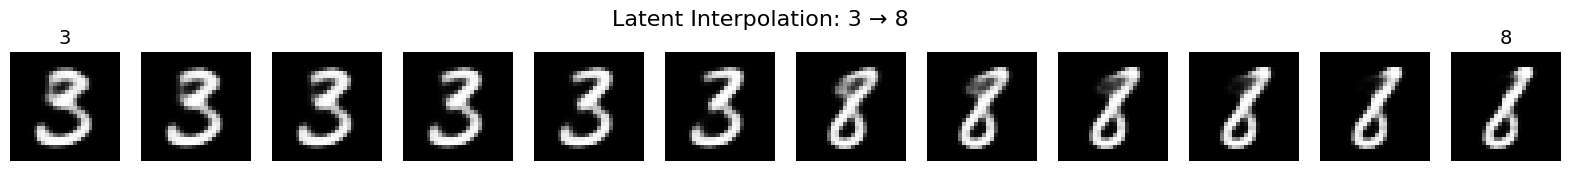

In [9]:
# ============================================
# 🌈 STEP 9: Latent Interpolation (潛在空間插值)
# ============================================
import torch
import matplotlib.pyplot as plt
import numpy as np

def interpolate_between_digits(model, digit_start=3, digit_end=8, steps=10):
    model.eval()
    with torch.no_grad():
        # 隨機從標準常態生成起點與終點的 latent 向量
        z_start = torch.randn(1, model.latent_dim).to(device)
        z_end = torch.randn(1, model.latent_dim).to(device)

        # 生成插值序列 (線性插值)
        z_interp = torch.stack([
            (1 - alpha) * z_start + alpha * z_end
            for alpha in np.linspace(0, 1, steps)
        ]).squeeze(1)

        # 對應的標籤
        y_interp = torch.tensor([digit_start] * (steps//2) + [digit_end] * (steps - steps//2)).to(device)

        # 解碼生成影像
        imgs = model.decode(z_interp, y_interp).cpu()

    # 顯示插值結果
    plt.figure(figsize=(20, 2))
    for i in range(steps):
        ax = plt.subplot(1, steps, i + 1)
        plt.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title(f"{digit_start}", fontsize=14)
        elif i == steps - 1:
            ax.set_title(f"{digit_end}", fontsize=14)
    plt.suptitle(f"Latent Interpolation: {digit_start} → {digit_end}", fontsize=16)
    plt.show()

# 執行範例：從 3 逐漸變成 8
interpolate_between_digits(model, digit_start=3, digit_end=8, steps=12)
